In [ ]:
import numpy as np
import pandas as pd
import string

In [ ]:
data=pd.read_csv('spam.tsv',sep='\t',names=('class','message'))
data

,class,message
0,ham,I've been searching for the right words to tha...
1,spam,Free entry in 2 a wkly comp to win FA Cup fina...
2,ham,"Nah I don't think he goes to usf, he lives aro..."
3,ham,Even my brother is not like to speak with me. ...
4,ham,I HAVE A DATE ON SUNDAY WITH WILL!!!
...,...,...
5562,spam,This is the 2nd time we have tried 2 contact u...
5563,ham,Will ü b going to esplanade fr home?
5564,ham,"Pity, * was in mood for that. So...any other s..."
5565,ham,The guy did some bitching but I acted like i'd...


In [ ]:
data.head()

,class,message
0,ham,I've been searching for the right words to tha...
1,spam,Free entry in 2 a wkly comp to win FA Cup fina...
2,ham,"Nah I don't think he goes to usf, he lives aro..."
3,ham,Even my brother is not like to speak with me. ...
4,ham,I HAVE A DATE ON SUNDAY WITH WILL!!!


In [ ]:
data.tail()

,class,message
5562,spam,This is the 2nd time we have tried 2 contact u...
5563,ham,Will ü b going to esplanade fr home?
5564,ham,"Pity, * was in mood for that. So...any other s..."
5565,ham,The guy did some bitching but I acted like i'd...
5566,ham,Rofl. Its true to its name


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5567 entries, 0 to 5566
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   class    5567 non-null   object
 1   message  5567 non-null   object
dtypes: object(2)
memory usage: 87.1+ KB


In [ ]:
#To convert data['class'] into 1 and 0
data['class']=data['class'].map({'ham':1,
                                 'spam':0
                                 })

In [ ]:
data.head()

,class,message
0,1,I've been searching for the right words to tha...
1,0,Free entry in 2 a wkly comp to win FA Cup fina...
2,1,"Nah I don't think he goes to usf, he lives aro..."
3,1,Even my brother is not like to speak with me. ...
4,1,I HAVE A DATE ON SUNDAY WITH WILL!!!


In [ ]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [ ]:
# remvoe the puncuvations

def remove_punc(text):
  text=''.join(char for char in text if char not in string.punctuation)
  return text

In [ ]:
print(remove_punc('...nivas..123'))

nivas123


In [ ]:
new_message=[remove_punc(i)for i in data['message']]


In [ ]:
data['new_message']=new_message
data.head()

,class,message,new_message
0,1,I've been searching for the right words to tha...,Ive been searching for the right words to than...
1,0,Free entry in 2 a wkly comp to win FA Cup fina...,Free entry in 2 a wkly comp to win FA Cup fina...
2,1,"Nah I don't think he goes to usf, he lives aro...",Nah I dont think he goes to usf he lives aroun...
3,1,Even my brother is not like to speak with me. ...,Even my brother is not like to speak with me T...
4,1,I HAVE A DATE ON SUNDAY WITH WILL!!!,I HAVE A DATE ON SUNDAY WITH WILL


In [ ]:
y=data['class'].values
x=data['new_message'].values
x

array(['Ive been searching for the right words to thank you for this breather I promise i wont take your help for granted and will fulfil my promise You have been wonderful and a blessing at all times',
       'Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005 Text FA to 87121 to receive entry questionstd txt rateTCs apply 08452810075over18s',
       'Nah I dont think he goes to usf he lives around here though', ...,
       'Pity  was in mood for that Soany other suggestions',
       'The guy did some bitching but I acted like id be interested in buying something else next week and he gave it to us for free',
       'Rofl Its true to its name'], dtype=object)

In [ ]:
x.dtype
#print(x.head())
print(x.dtype)

object


In [ ]:
y

array([1, 0, 1, ..., 1, 1, 1])

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
x_train.shape

(4453,)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer

cv=CountVectorizer(stop_words='english')
x_train_cv=cv.fit_transform(x_train)
x_test_cv=cv.transform(x_test)
tf=TfidfVectorizer(stop_words='english')
x_train_tf=tf.fit_transform(x_train)
x_test_tf=tf.transform(x_test)




In [ ]:
from imblearn.over_sampling import  SMOTE
sm=SMOTE()
x_train_cv_sm,y_train_sm=sm.fit_resample(x_train_cv,y_train)
x_train_tf_sm, y_train_tf_sm = sm.fit_resample(x_train_tf, y_train)

In [ ]:
#import pandas as pd

print(pd.Series(y_train).value_counts())
print(pd.Series(y_train_sm).value_counts())

1    3852
0     601
Name: count, dtype: int64
0    3852
1    3852
Name: count, dtype: int64


In [ ]:
from sklearn.naive_bayes import BernoulliNB
bn=BernoulliNB()
bn.fit(x_train_cv_sm,y_train_sm)

BernoulliNB()

In [ ]:
y_pred=bn.predict(x_test_cv)
y_pred

array([1, 1, 1, ..., 1, 1, 0])

In [ ]:
y_test

array([1, 1, 1, ..., 1, 1, 1])

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9631956912028725
F1 Score: 0.9785676947203346
              precision    recall  f1-score   support

           0       0.81      0.94      0.87       145
           1       0.99      0.97      0.98       969

    accuracy                           0.96      1114
   macro avg       0.90      0.96      0.92      1114
weighted avg       0.97      0.96      0.96      1114



In [ ]:
text = input("Enter message: ")

textinput = cv.transform([text])  # Put text inside a list

prediction = bn.predict(textinput)

if prediction[0] == 1:
    print("not spam")
else:
    print("spam")

Enter message: get money
not spam


In [ ]:
bn.fit(x_train_tf_sm,y_train_sm)

BernoulliNB()

In [ ]:
y_pred=bn.predict(x_test_tf)
y_pred

array([1, 1, 1, ..., 1, 1, 1])

In [ ]:
y_test

array([1, 1, 1, ..., 1, 1, 1])

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9865350089766607
F1 Score: 0.9923195084485407
              precision    recall  f1-score   support

           0       1.00      0.90      0.95       145
           1       0.98      1.00      0.99       969

    accuracy                           0.99      1114
   macro avg       0.99      0.95      0.97      1114
weighted avg       0.99      0.99      0.99      1114



In [ ]:
text = input("Enter message: ")

textinput = tf.transform([text])  # Put text inside a list

prediction = bn.predict(textinput)

if prediction[0] == 1:
    print("not spam")
else:
    print("spam")

Enter message: 5666
not spam


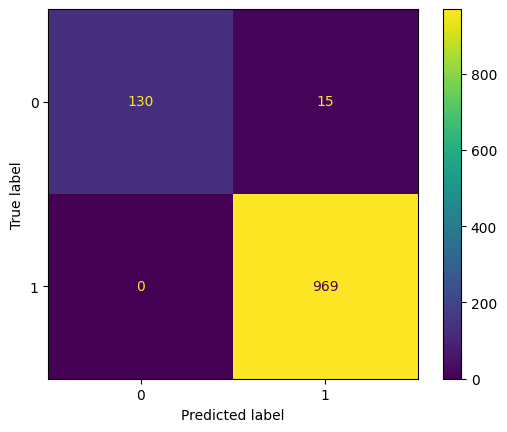

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()

In [ ]:
from sklearn.naive_bayes import MultinomialNB
ml=MultinomialNB()
ml.fit(x_train_cv_sm,y_train_sm)

MultinomialNB()

In [ ]:
y1_pred=ml.predict(x_test_cv)
y1_pred

array([1, 1, 1, ..., 1, 1, 0])

In [ ]:

print("Accuracy:", accuracy_score(y_test, y1_pred))
print("F1 Score:", f1_score(y_test, y1_pred))
print(classification_report(y_test, y1_pred))

Accuracy: 0.9649910233393177
F1 Score: 0.9796557120500783
              precision    recall  f1-score   support

           0       0.82      0.94      0.87       145
           1       0.99      0.97      0.98       969

    accuracy                           0.96      1114
   macro avg       0.90      0.95      0.93      1114
weighted avg       0.97      0.96      0.97      1114



In [ ]:
ml.fit(x_train_tf_sm,y_train_sm)

MultinomialNB()

In [ ]:
y_pre=ml.predict(x_test_tf)


In [ ]:

print("Accuracy:", accuracy_score(y_test, y_pre))
print("F1 Score:", f1_score(y_test, y_pre))
print(classification_report(y_test, y_pre))

Accuracy: 0.9640933572710951
F1 Score: 0.9790575916230366
              precision    recall  f1-score   support

           0       0.80      0.96      0.87       145
           1       0.99      0.96      0.98       969

    accuracy                           0.96      1114
   macro avg       0.90      0.96      0.93      1114
weighted avg       0.97      0.96      0.97      1114



In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(x_train_tf_sm, y_train_sm)

y_pred = lr.predict(x_test_tf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9793536804308797
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       145
           1       0.99      0.99      0.99       969

    accuracy                           0.98      1114
   macro avg       0.95      0.96      0.95      1114
weighted avg       0.98      0.98      0.98      1114



In [ ]:
import pickle

pickle.dump(ml, open('spam_model.pkl', 'wb'))
pickle.dump(tf, open('tfidf_vectorizer.pkl', 'wb'))

In [ ]:
import pickle

model = pickle.load(open('spam_model.pkl', 'rb'))
vectorizer = pickle.load(open('tfidf_vectorizer.pkl', 'rb'))

msg = input("Enter message: ")

msg_tf = vectorizer.transform([msg])

pred = model.predict(msg_tf)

if pred[0] == 0:
    print("Spam")
else:
    print("Not Spam")

Enter message: Congratulations! You have won a free iPhone. Claim now.
Spam


In [ ]:
from google.colab import files

files.download('spam_model.pkl')
files.download('tfidf_vectorizer.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>